## Brute-force (grid) optimization of `t` and `e`
look into 
https://github.com/jpivarski/pyminuit

After Siame et al. 2004 (their optimization and "Quality factor" maps") combined with an iteration over different depth profiles sampled from nuclide concentrations with Gaussian uncertainties after Braucher et al 2009. Uncertainty in density is possible.

This code does not invert for inheritance.

**COPY THIS FILE AND MESS WITH A NEW DATA SET**


In [1]:
import math
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import cm

import scipy
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar


# contributions of different path ways:
n = 97.85/100 # spallation
m1 = 1.5/100 # negative muon
m2 = 0.65/100 # fast muon

# effective attenuation lengths:
Ln = 150 #g/cm2
Lm1 = 1500 #g/cm2
Lm2 = 5300 #g/cm2

# decay constant:
lambdaBe = 4.998e-7 # yr-1 # ± 0.043 × 10−7 yr−1

rho = 2.0 #g/cm3

def toE(e): return e*1e4/rho # g/cm2/yr to mm/kyr
def toe(E): return E*rho/1e4 # mm/kyr to g/cm2/yr
def toX(x): return x/rho # g/cm2 to cm
def tox(X): return X*rho # cm to g/cm2

# variable definitions:
# depth x
x_min, x_max = 0, 1000 # g/cm2
X_min, X_max = toX(x_min), toX(x_min) # cm

# erosion rate e
e_min, e_max = 0, 0.1 # g/cm2/yr
E_min, E_max = toE(e_min), toE(e_max) # mm/kyr

# exposure time t
#t_min, t_max = 0, np.inf # yr (>0, <inf)
t_min, t_max = 1, 5e+6 # yr (>0, <inf)


def get_chi2_vec(*, Ni, si, Npred):
    # Ni, dNii are 1D arrays of nuclide concentrations at different depths
    # if Npred is a 1D arrays of predicted nuclide concentrations
    #    the function returns a 1D array of Chi2 values  # CHECK THIS
    
    # if Npred = get_Nofetx_vec(ee, tt, xx)
    #    the function returns a 3D array of Chi2 values for a range of tt and ee values
    
    # note that depth x must be the last coordinate in Npred in order for the broadcasting to work correctly
    return ((Npred-Ni)/si)**2/len(Ni)

    
# eqn 7:
def alphax(x): return n*np.exp(-x/Ln)
def betax(x): return m1*np.exp(-x/Lm1)
def gammax(x): return m2*np.exp(-x/Lm2)

# eqn 8:
def epsilon1(e): return 1/(e/Ln+lambdaBe)
def epsilon2(e): return 1/(e/Lm1+lambdaBe)
def epsilon3(e): return 1/(e/Lm2+lambdaBe)

def get_Nofetx(*, e, t, x):
    # only one of the variable may be vectorized
    return (epsilon1(e)*alphax(x)*(-np.expm1(-t/epsilon1(e))) +
            epsilon2(e)*betax(x)*(-np.expm1(-t/epsilon2(e))) +
            epsilon3(e)*gammax(x)*(-np.expm1(-t/epsilon3(e)))
           )
    
def get_Nofetx_vec(*, e, t, x):
    # todo: test and convert to np.array
    tt = np.reshape(t, (1, len(t), 1))
    ee = np.reshape(e, (len(e), 1, 1))
    xx = np.reshape(x, (1, 1, len(x)))

    return (epsilon1(ee) * alphax(xx) * (-np.expm1(-tt/epsilon1(ee))) +
            epsilon2(ee) * betax(xx) * (-np.expm1(-tt/epsilon2(ee))) +
            epsilon3(ee) * gammax(xx) * (-np.expm1(-tt/epsilon3(ee)))
           )


e0, e1 = e_min, e_max
t0, t1 = t_min, t_max

bounds = {'e0':e0, 'e1':e1, 't0':t0, 't1':t1}

results = {}
for key in ['ie', 'it', 'e', 'E', 't', 'chi2']: results[key] = []

margins = {}
for key in ['e', 'E', 't', 'chi2']: margins[key] = []

noi = 100 #number of iterations


In [2]:
def remove_outofbounds(results, verbose=True):
    # revised = remove_outofbounds(results)
    
    revised = deepcopy(results)
    outstring = [] 
    for key in ['e', 'E', 't']: margins[key]=[]

    it0 = (results['it']==0).nonzero()[0]                    # find indices where t is at min
    if len(it0)>0:
        outstring.append("    bounds['t0'] excludes n={} data points".format(len(it0)))
        revised['e'][it0] = np.nan

    it1 = (results['it']==(len(tt)-1)).nonzero()[0]          # find indices where t is at max
    if len(it1)>0:
        outstring.append("    bounds['t1'] excludes n={} data points".format(len(it1)))
        revised['e'][it1] = np.nan

    ie0 = (results['ie']==0).nonzero()[0]                    # find indices where e is at min
    if len(ie0)>0:
        outstring.append("    bounds['e0'] excludes n={} data points".format(len(ie0)))
        revised['e'][ie0] = np.nan

    ie1 = (results['ie']==(len(ee)-1)).nonzero()[0]          # find indices where e is at max
    if len(ie1)>0:
        outstring.append("    bounds['e1'] excludes n={} data points".format(len(ie1)))
        revised['e'][ie1] = np.nan

    keep = ~np.isnan(revised['e'])
    for key in revised.keys():
        revised[key] = revised[key][keep]

    if (len(revised['e']) < len(results['e'])):
        outstring = '\n'.join(o for o in outstring)
        print("\n>>> {:.0f}% ".format(100 * (1 - len(revised['e']) / len(results['e']))) +
              "of the modelled data points are outside of the defined parameter space!")
        print(outstring)
    else:
        print("\n>>> All modelled data points are within the defined parameter space.")
    return revised

## Plotting functions
I need to look into what colormesh returns so i can use `plot_time_erate_map()` to cenerate custom plots. At the moment only `plot_Npred_map()` and `plot_Chi_map()` are working.

In [3]:
def plot_Qf_map(*, ax, ee, tt, Chi, NN, pt=(np.nan, np.nan), title=None): 
    "plot_Qf_map"
    
    """UNCOMMENT OR MODIFY BUT MAKE SURE CONSISTENT"""
    #yaxis, ylabel, pt = tt/1e3, 'exposure time [kyr]', pt[1]/1e3
    yaxis, ylabel, pt_t = tt/1e6, 'exposure time [Myr]', pt[1]/1e6
    
    #xaxis, xlabel, pe = toE(ee), 'denudation rate [mm/kyr]', toE(pt[0])
    xaxis, xlabel, pt_e = ee, 'denudation rate [cm/g/yr]', pt[0]
        
    a = (len(NN)-2)/2
    Qf = 100*scipy.special.gammainc(a, Chi/2)/math.gamma(a) # = 1-probability

    sc = ax.pcolormesh(xaxis, yaxis, Qf[:,:,0].T,
        norm=colors.Normalize(vmin=0, vmax=100),
        alpha=.3, cmap='viridis_r')

    #plt.colorbar(sc)
    
    "Qf contour:"
    #conf_levels = np.array([68.3, 95.4, 99.7])
    conf_levels = np.array([68.3, 95.4])
    cs = ax.contour(xaxis, yaxis, Qf[:,:,0].T, conf_levels, colors='k', linewidths=[2,1])
    "Qf contour labels:"    
    #_ = ax.clabel(cs, cs.levels, inline=True, fontsize=8)
    
    bestfit = np.min(Qf.ravel())
    
    _ = ax.contour(xaxis, yaxis, Qf[:,:,0].T, [1.01*bestfit], colors='r', linewidths=1)
    
    ax.plot(pt_e, pt_t, '*k')

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title)
    return Qf

## STEP 1. Input data and depth profile with uncertainty in `rho`
- `XX` : depths in cm
- `NN` : corresponding nuclide concentrations in atoms/g
- `dN` : uncertatinties in atoms/g

- `P0` : surface production rate
- `rho`, `drho` : density and relative uncertainty (may be zero)

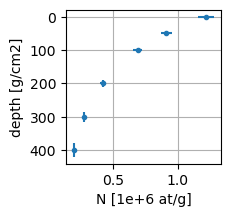

In [5]:
XX = np.array([0,25,50,100,150,200]) # x [g/cm2]
NN = np.array([262888,190006,137742,73352,40164,23004]) # [at/g] (20 ka)
NN = np.array([1216246,910993,691338,418744,275870,199762]) # [at/g] (800 ka)

#xx = tox(np.array([0,200,500,800,1000,1200])) # x [g/cm2]
#NN = np.array([262888,23004,4197,2957,2491,2122]) # [at/g] (20 ka)
#NN = np.array([1216246,199762,97433,74902,64130,55404]) # [at/g] (800 ka)

dN = 0.05*NN # 3% uncertainty

P0 = 15 # atoms/g/yr

rho = 2 # g/cm3
drho = 0.05 # relative uncertainty on rho; may be zero
rho0, rho1 = (1-drho)*rho, (1+drho)*rho

fig, ax = plt.subplots(figsize=(2,2))
ax.errorbar(NN/1e6, tox(XX), xerr=dN/1e6, yerr = tox(XX)*drho, fmt='.')
ax.invert_yaxis()
ax.set_ylabel("depth [g/cm2]")
ax.set_xlabel("N [1e+6 at/g]")
ax.grid()

## Step 2. Initial gridded optimization
Meshgrid for three different densities. Rerun and adjust boundaries (with `e` in g/cm2/yr).

Note that `tt` can be defined in log-space for the computation but the plotting will remain lin-space unless changed in `plot_Qf_map()`. 

rho=1.90 g/cm3  ,  e=0.00199 g/cm2/yr =10.5 mm/kyr  ,  t=665169 yr  ,  chi2=0.03341
rho=2.00 g/cm3  ,  e=0.00200 g/cm2/yr =10.0 mm/kyr  ,  t=819618 yr  ,  chi2=0.00007
rho=2.10 g/cm3  ,  e=0.00199 g/cm2/yr =9.5 mm/kyr  ,  t=980251 yr  ,  chi2=0.03231


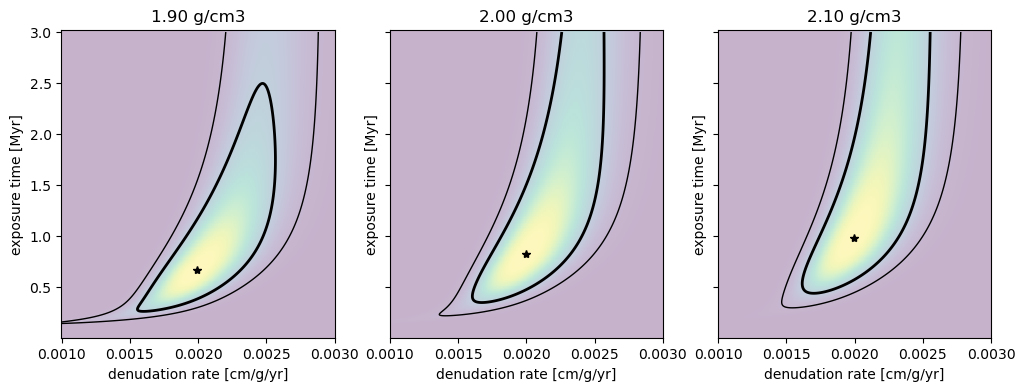


>>> Bold line: 68.3% (1 sigma), thin line: 95.4% (2 simga)


In [6]:
"""Initial optimization with meshgrid using analytical data"""

# reset the bounds to factory default:
e0, e1 = e_min, e_max
t0, t1 = t_min, t_max


"""MANUALLY ADJUST THESE BOUNDS FOR A NEW DATASET"""
e0 = 0.001 #toe(0)
e1 = 0.003
#t0 = 10
t1 = 3000000

Qfs = []

fig, axs = plt.subplots(1,3, figsize=(12,4), sharey=True)
    
for i, rho in enumerate([rho0, (rho0+rho1)/2, rho1]):

    ee = np.linspace(e0, e1, 501) # e [g/cm2]
    tt = np.logspace(np.log10(t0), np.log10(t1), 1001) # t [yr]
    #tt = np.linspace(t0, t1, 1001) # t [yr]

    Npred = P0*get_Nofetx_vec(e=ee, t=tt, x=tox(XX))        

    Chi = get_chi2_vec(Ni=NN, si=dN, Npred=Npred) # Chi2 values for all depth and all e,t-pairs
    Chi = Chi.sum(axis=2, keepdims=True)

    #a = (len(NN)-2)/2
    #Qf = 100*scipy.special.gammainc(a, Chi)/math.gamma(a) # = 1-probability

    # find the best-fit parameter set (median of best-fit area) from Chi2
    ie, it, ix = (Chi == np.nanmin(Chi)).nonzero()
    ie = int(np.nanmedian(ie))
    it = int(np.nanmedian(it))
    ix = int(np.nanmedian(ix)) # ix=0 since Chi is the sum over the depth profile
    print("rho={:.2f} g/cm3  ".format(rho), end=',  ')
    print("e={:.5f} g/cm2/yr ={:.1f} mm/kyr  ".format(float(ee[ie]), toE(float(ee[ie]))), end=',  ')
    print("t={:.0f} yr  ".format(float(tt[it])), end=',  ')
    print("chi2={:.5f}".format(float(Chi[ie, it, ix])))
    
    Qfs.append(plot_Qf_map(ax=axs[i], ee=ee, tt=tt, Chi=Chi, NN=NN,
                           pt=(ee[ie], tt[it]), title="{:.2f} g/cm3".format(rho)))         

    #print("\n-> rho: {} g/cm3".format(rho))
    #print("t_fit : {:.1f} kyr".format(t_fit/1e3))
    #print("e_fit : {:.1f} mm/kyr".format(toE(e_fit)))
    #print("e_fit : {:.5f} g/cm2/yr".format(e_fit))
    #print("Chi2 : {:.2e}".format(chi2))
    #print("dt = {:.0f} yr, de = {:.3f} mm/kyr".format(tt[2]-tt[1], toE(ee[2]-ee[1])))

plt.show()
print("\n>>> Bold line: 68.3% (1 sigma), thin line: 95.4% (2 simga)")

## Step 3. Iterate over different data combinations (possibly including different densities)
The Qf maps should give an indication of how well `e` and `t` are constrained and what the likely parameter range is.


In [7]:
"""MANUALLY NARROW DOWN THE BOUNDS"""
rho=2
bounds = {'e0':0.0015, 'e1':.0025, 't0':300000, 't1':2.5e6}

ee = np.linspace(bounds['e0'], bounds['e1'], 501) # e [g/cm2]
tt = np.logspace(np.log10(bounds['t0']), np.log10(bounds['t1']), 1001) # t [yr]
#tt = np.linspace(bounds['t0'], bounds['t1'], 1001) # t [yr]

noi = 100

data = NN
for i in range(noi):
    Ci = [int(np.random.normal(N, np.sqrt(d),1)) for N,d in zip(NN, dN)]
    Ci = np.asarray(Ci)
    data = np.vstack((data, Ci))
    
"""CHOOSE CONSTANT OR VARIABLE DENSITY FOR THE ITERATION"""
rho_vals = (  # avoid using 'rho' as this variable may have been overwritten since the user input
    np.random.random(size=noi+1) * (rho1-rho0) + rho0)
rho_vals[0] = (rho1+rho0)/2

# alternatively leave rho constant:
#rho_vals = np.ones((noi, ))*2.0#*(rho1+rho0)/2

In [8]:
"""Initial low-resolution iteration"""
results = {'ie':[], 'it':[], 'e':[],  'E':[], 't':[], 'chi2':[], 'rho':[], 'iN':[]}

print("Running {} iterations: ".format(len(data)), end='')
for i, N, rho in zip(range(len(data)), data, rho_vals): # updating the variable rho for correct toE()!!
    print(i, end='..')
    Npred = P0*get_Nofetx_vec(e=ee, t=tt, x=tox(XX))        

    Chi = get_chi2_vec(Ni=N, si=dN, Npred=Npred) # Chi2 values for all depth and all e,t-pairs
    Chi = Chi.sum(axis=2, keepdims=True)

    #a = (len(NN)-2)/2
    #Qf = 100*scipy.special.gammainc(a, Chi)/math.gamma(a) # = 1-probability

    # find the best-fit parameter set (median of best-fit area) from Chi2
    ie, it, ix = (Chi == np.nanmin(Chi)).nonzero()
    ie, it, ix = int(np.nanmedian(ie)), int(np.nanmedian(it)), int(np.nanmedian(ix))
    results['ie'].append(ie)
    results['it'].append(it)
    results['e'].append(float(ee[ie]))
    results['E'].append(float(toE(ee[ie]))) # using the current value for rho!!
    results['t'].append(float(tt[it]))
    results['chi2'].append(float(Chi[ie, it, ix]))
    results['rho'].append(rho) # density
    results['iN'].append(i) # index in data (and in rho_vals)
    
print("Done!")
for key in results.keys(): results[key] = np.array(results[key])
    
original = deepcopy(results)    
results = remove_outofbounds(results)


Running 101 iterations: 0..1..2..3..4..5..6..7..8..9..10..11..12..13..14..15..16..17..18..19..20..21..22..23..24..25..26..27..28..29..30..31..32..33..34..35..36..37..38..39..40..41..42..43..44..45..46..47..48..49..50..51..52..53..54..55..56..57..58..59..60..61..62..63..64..65..66..67..68..69..70..71..72..73..74..75..76..77..78..79..80..81..82..83..84..85..86..87..88..89..90..91..92..93..94..95..96..97..98..99..100..Done!

>>> All modelled data points are within the defined parameter space.


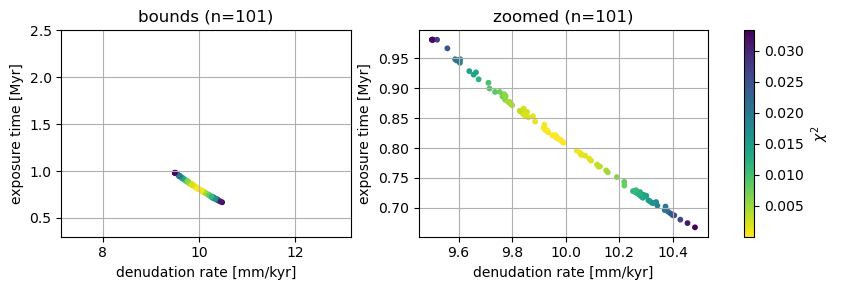


>>> Parameter space is constrained to:
{'e0': 0.0015, 'e1': 0.0025, 't0': 300000, 't1': 2500000.0}

>>> Density varies between 1.90 and 2.10 g/cm3


In [9]:
"""Plot iteration"""
fig, axs = plt.subplots(1,2, figsize=(8,3))

ax = axs[0]
sc = ax.scatter((results['E']), results['t']/1e6, c=results['chi2'], s=10, cmap="viridis_r")

ax.set_xlim(bounds['e0']/max(rho_vals)*1e4, bounds['e1']/min(rho_vals)*1e4)
ax.set_ylim((bounds['t0']/1e6, bounds['t1']/1e6))
ax.set_xlabel("denudation rate [mm/kyr]")
ax.set_ylabel("exposure time [Myr]")
ax.set_title("bounds (n={})".format(len(results['e'])))

ax.grid()

ax = axs[1]
sc = ax.scatter(results['E'], results['t']/1e6, c=results['chi2'], s=10, cmap="viridis_r")
ax.set_xlabel("denudation rate [mm/kyr]")
ax.set_ylabel("exposure time [Myr]")
ax.set_title("zoomed (n={})".format(len(results['e'])))

#ax.plot(margins['E'], margins['t']/1e6, 'or', ms=6)

ax.grid()

plt.tight_layout()

_ = plt.colorbar(sc, ax=axs, orientation='vertical', fraction=.05, label="$\chi ^2$")

plt.show()
print("\n>>> Parameter space is constrained to:")
print(bounds)
if min(rho_vals)==max(rho_vals):
    print("\n>>> Density is constant {} g/cm3".format(rho))
else:
    print("\n>>> Density varies between {:.2f} and {:.2f} g/cm3".format(min(rho_vals), max(rho_vals)))

**These plots are highly sensitive to the parameter space (variable `bounds`) and resolution in `ee` and `tt`.**
If the results look funny check the following:
- Adjust the x-scale or y-scale manually; if the limits are very narrow the data looks gridded.
- Revisit the Qf maps to make sure the solution is within `bounds`.
- Increase the resolution in `tt` and `ee` but keep in mind this will seriously slow things down.
- Narrow down the parameter space; you will get a warning if the parameter space is too narrow.

A parameter space that is too small will be indicated by a message

`>>> 27% of the modelled data points are outside of the defined parameter space!`<br>
 `   bounds['e1'] excludes n=27 data points`
 
by the function `remove_outofbounds()`

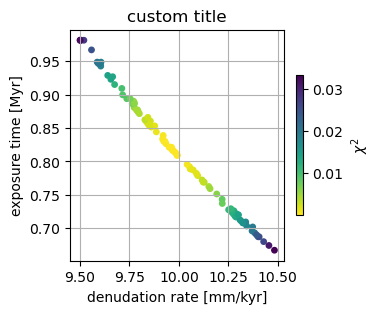

In [11]:
"""PLOT WITH MANUAL BOUNDARIES""" #available from TEMPLATES

fig, ax = plt.subplots(figsize=(3,3))

sc = ax.scatter((results['E']), results['t']/1e6, c=results['chi2'], s=15, cmap="viridis_r")
#ax.set_xlim((22, 23))
#ax.set_ylim((1, 2))
ax.set_xlabel("denudation rate [mm/kyr]")
ax.set_ylabel("exposure time [Myr]")
ax.set_title("custom title")

plt.colorbar(sc, ax=ax, orientation='vertical', fraction=.03, label="$\chi ^2$")

ax.grid()

## Templates - Do Not Delete

In [ ]:
"""PLOT Qf MAP"""

fig, ax = plt.subplots(figsize=(4,4))

rho = 2.0

ee = np.linspace(e0, e1, 501) # e [g/cm2]
tt = np.logspace(np.log10(t0), np.log10(t1), 1001) # t [yr]
#tt = np.linspace(t0, t1, 1001) # t [yr]

Npred = P0*get_Nofetx_vec(e=ee, t=tt, x=tox(XX))        

Chi = get_chi2_vec(Ni=NN, si=dN, Npred=Npred) # Chi2 values for all depth and all e,t-pairs
Chi = Chi.sum(axis=2, keepdims=True)
    
ie, it, ix = (Chi == np.nanmin(Chi)).nonzero()
ie, it, ix = int(np.nanmedian(ie)), int(np.nanmedian(it)), int(np.nanmedian(ix))

Qf = plot_Qf_map(ax=ax, ee=ee, tt=tt, Chi=Chi, NN=NN,
                 pt=(ee[ie], tt[it]), title="{:.2f} g/cm3".format(rho))

In [ ]:
"""PLOT ITERATION RESULTS"""

fig, ax = plt.subplots(figsize=(5,4))

sc = ax.scatter(np.array(results['E']), np.array(results['t'])/1e6, c=np.array(results['chi2']),
                s=15, cmap="viridis_r",
                vmin=np.nanmin(results['chi2']), vmax=np.nanmax(results['chi2']))
ax.set_xlim((22, 23))
ax.set_ylim((1, 2))
ax.set_xlabel("denudation rate [mm/kyr]")
ax.set_ylabel("exposure time [Myr]")
ax.set_title("custom title")

plt.colorbar(sc, ax=ax, orientation='vertical', fraction=.03, label="$\chi ^2$")

ax.grid()